# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [14]:
!pip install gdown

In [15]:
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [16]:
url='https://drive.google.com/uc?id=113CiDgR6pTHNwYPARdXxSKGecpR9qXIo&export=download'

output='am_pm.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=113CiDgR6pTHNwYPARdXxSKGecpR9qXIo&export=download
To: /home/mirshod/Desktop/DSB10_Intro_to_ML.ID_886521-1/src/ex01/am_pm.csv
100%|██████████| 966/966 [00:00<00:00, 4.66MB/s]


'am_pm.csv'

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [17]:
df=pd.read_csv('am_pm.csv')
df

,date,am,pm,target,predict
0,2020-04-17,21,2,True,False
1,2020-04-18,1,68,False,True
2,2020-04-19,18,15,False,True
3,2020-04-20,2,23,True,True
4,2020-04-21,0,25,True,True
5,2020-04-22,0,28,True,True
6,2020-04-23,10,33,True,True
7,2020-04-24,2,14,True,True
8,2020-04-25,30,74,False,True
9,2020-04-26,28,233,False,True


In [18]:
X = df[['am', 'pm']]
y = df['target']
prediction = df['predict']
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X, y)

LogisticRegression(fit_intercept=False, random_state=21)

Now, let's plot the data with the decision boundary, coloring the points by the actual target.

/home/mirshod/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


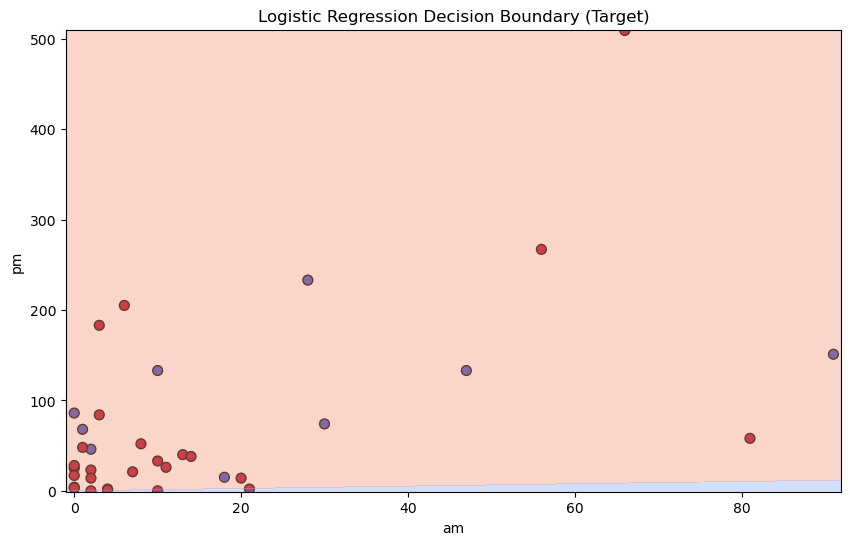

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['am'], df['pm'], c=y, cmap='coolwarm', s=50, edgecolors='k')


x_min, x_max = X['am'].min() - 1, X['am'].max() + 1
y_min, y_max = X['pm'].min() - 1, X['pm'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Target)')
plt.xlabel('am')
plt.ylabel('pm')
plt.show()

And now, the same plot, but with colors based on the model's predictions.

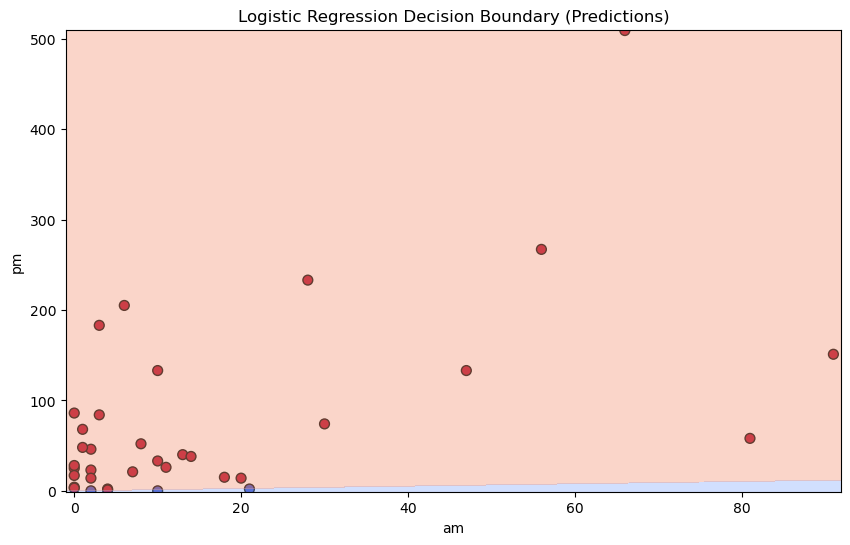

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['am'], df['pm'], c=model.predict(X), cmap='coolwarm', s=50, edgecolors='k')


plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Predictions)')
plt.xlabel('am')
plt.ylabel('pm')
plt.show()

In [21]:
accuracy = accuracy_score(y, df['predict'])
print(f"Accuracy of Logistic Regression model: {accuracy:.4f}")

Accuracy of Logistic Regression model: 0.6286


## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [24]:
model2=LogisticRegression(random_state=21, fit_intercept=False)
model2.fit(X_scaled, y)

LogisticRegression(fit_intercept=False, random_state=21)

In [25]:
acc_score=accuracy_score(y, model2.predict(X_scaled))
print(f"Accuracy of Logistic Regression model: {(acc_score*100):.2f}%")

Accuracy of Logistic Regression model: 74.29%


In [26]:
xsc_min, xsc_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
ysc_min, ysc_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xxsc, yysc = np.meshgrid(
    np.linspace(xsc_min, xsc_max, 200),
    np.linspace(ysc_min, ysc_max, 200)
)

Z=model2.predict(np.c_[xxsc.ravel(), yysc.ravel()])
Z=Z.reshape(xxsc.shape)

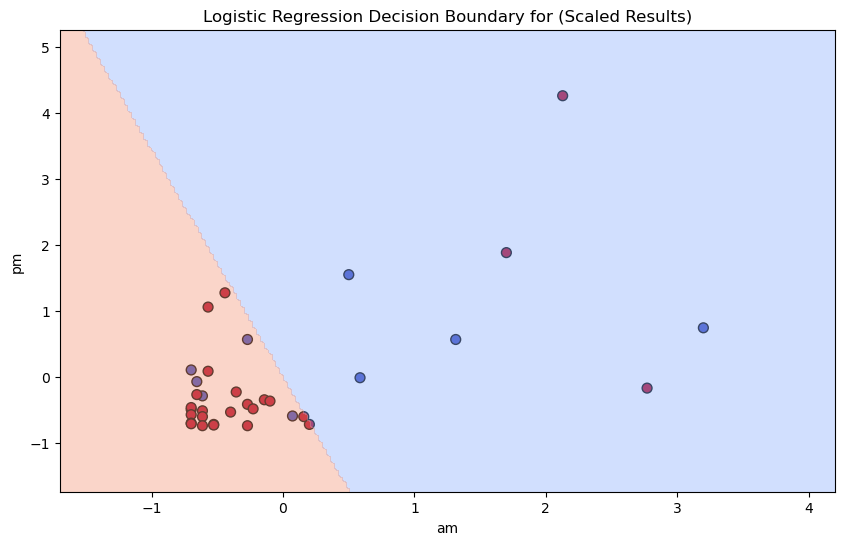

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k')

plt.contourf(xxsc, yysc, Z, alpha=0.4, cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary for (Scaled Results)')
plt.xlabel('am')
plt.ylabel('pm')
plt.show()

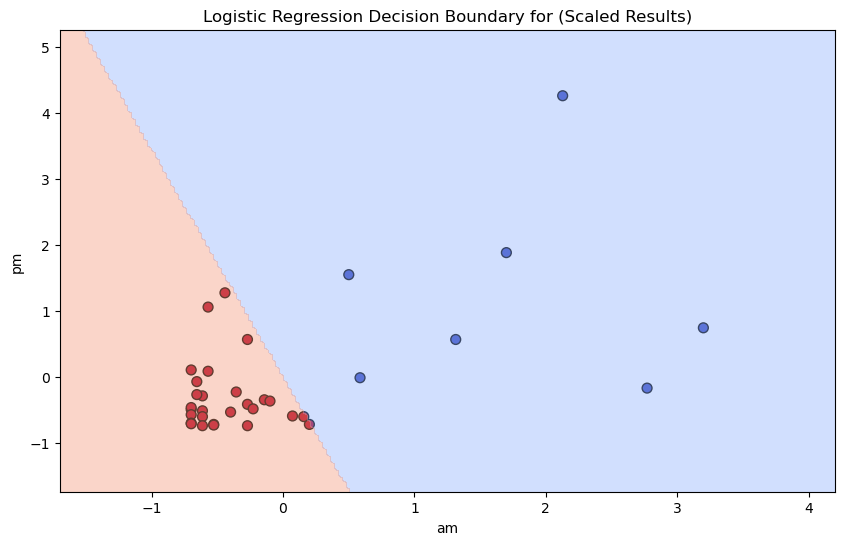

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model2.predict(X_scaled), s=50, cmap='coolwarm', edgecolors='k')

plt.contourf(xxsc, yysc, Z, alpha=0.4, cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary for (Scaled Results)')
plt.xlabel('am')
plt.ylabel('pm')
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [29]:
from sklearn.svm import SVC

Try to change kernel values with belov,
### Accuracy of Linear SVM model: 71.43%
**``kernel=linear``**
### Accuracy of Polynomial SVM model: 74.29%
**``kernel=poly``**
### Accuracy of Radial SVM model: 74.29%
**``kernel=rbf``**
and check their graphs!


In [30]:
svm_rbf=SVC(kernel='rbf', probability=True, random_state=21)
svm_rbf.fit(X_scaled, y)

SVC(probability=True, random_state=21)

In [31]:
acc_score=accuracy_score(y, svm_rbf.predict(X_scaled))
print(f"Accuracy of Radial SVM model: {(acc_score*100):.2f}%")

Accuracy of Radial SVM model: 74.29%


In [32]:
Z=svm_rbf.predict(np.c_[xxsc.ravel(), yysc.ravel()])
Z=Z.reshape(xxsc.shape)

Text(0, 0.5, 'pm')

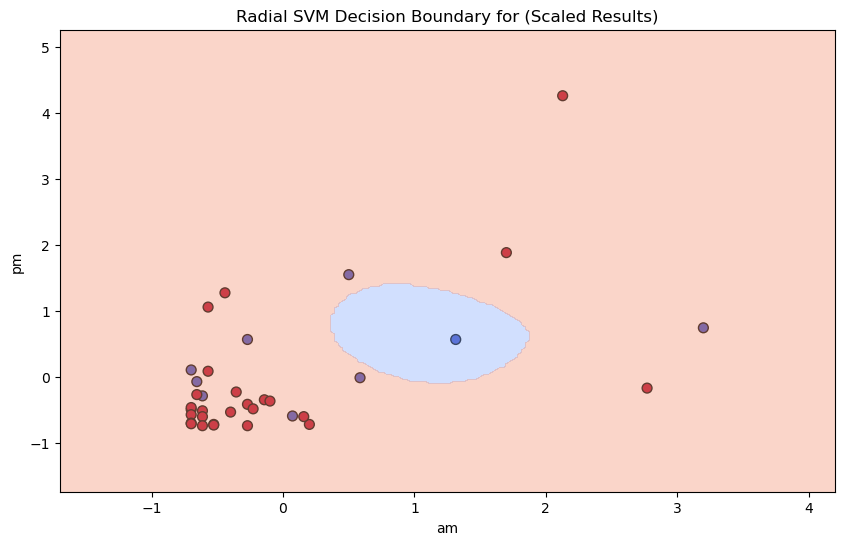

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:,0], X_scaled[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k')
plt.contourf(xxsc, yysc, Z, alpha=0.4, cmap='coolwarm')
plt.title('Radial SVM Decision Boundary for (Scaled Results)')
plt.xlabel('am')
plt.ylabel('pm')

Text(0, 0.5, 'pm')

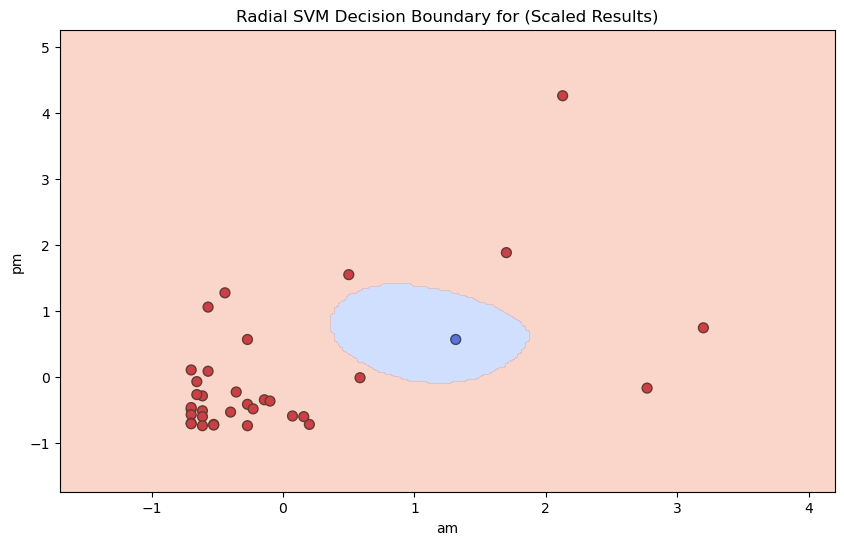

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:,0], X_scaled[:, 1], c=svm_rbf.predict(X_scaled), s=50, cmap='coolwarm', edgecolors='k')
plt.contourf(xxsc, yysc, Z, alpha=0.4, cmap='coolwarm')
plt.title('Radial SVM Decision Boundary for (Scaled Results)')
plt.xlabel('am')
plt.ylabel('pm')

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [35]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [36]:
dtc=DecisionTreeClassifier(max_depth=6, random_state=42)
dtc.fit(X_scaled, y)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [37]:
acc_score=accuracy_score(y, dtc.predict(X_scaled))
print(f"Accuracy of Decision Tree model: {(acc_score*100):.2f}%")

Accuracy of Decision Tree model: 100.00%


In [38]:
Z=dtc.predict(np.c_[xxsc.ravel(), yysc.ravel()])
Z=Z.reshape(xxsc.shape)

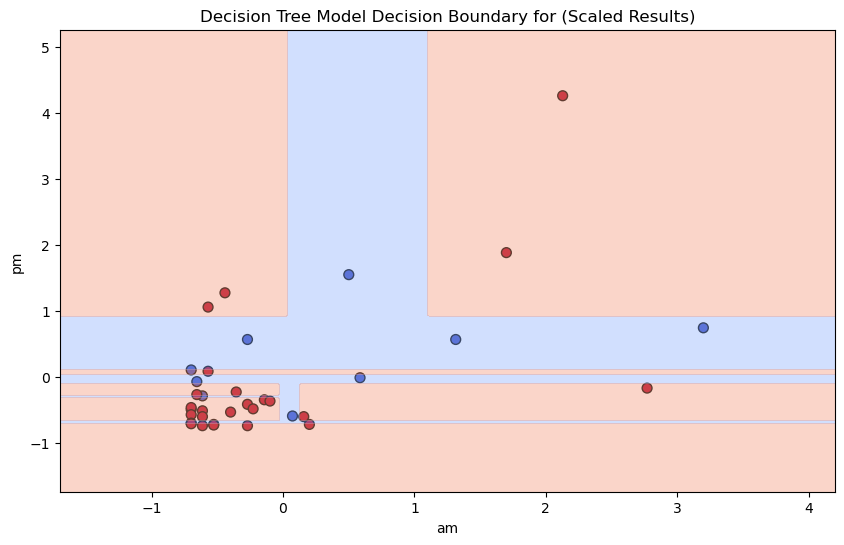

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:,0], X_scaled[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k')
plt.contourf(xxsc, yysc, Z, alpha=0.4, cmap='coolwarm')
plt.title('Decision Tree Model Decision Boundary for (Scaled Results)')
plt.xlabel('am')
plt.ylabel('pm')
plt.show()

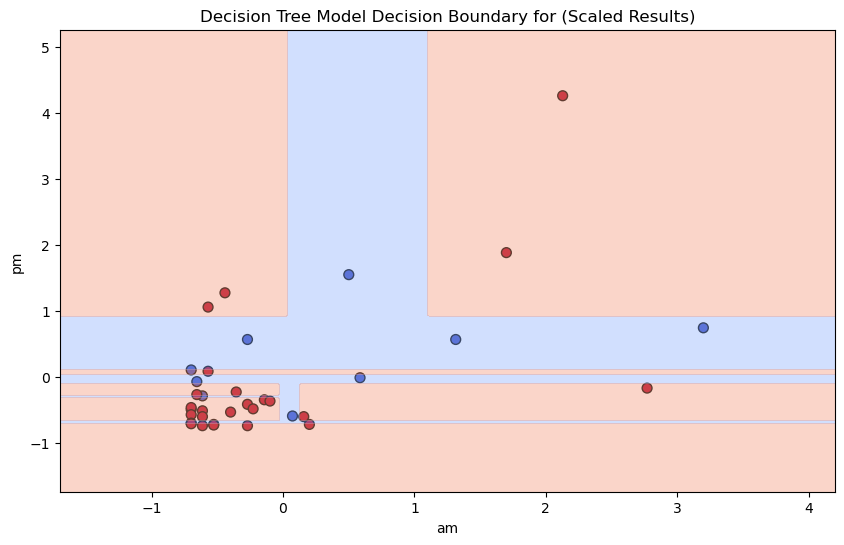

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:,0], X_scaled[:, 1], c=dtc.predict(X_scaled), s=50, cmap='coolwarm', edgecolors='k')
plt.contourf(xxsc, yysc, Z, alpha=0.4, cmap='coolwarm')
plt.title('Decision Tree Model Decision Boundary for (Scaled Results)')
plt.xlabel('am')
plt.ylabel('pm')
plt.show()

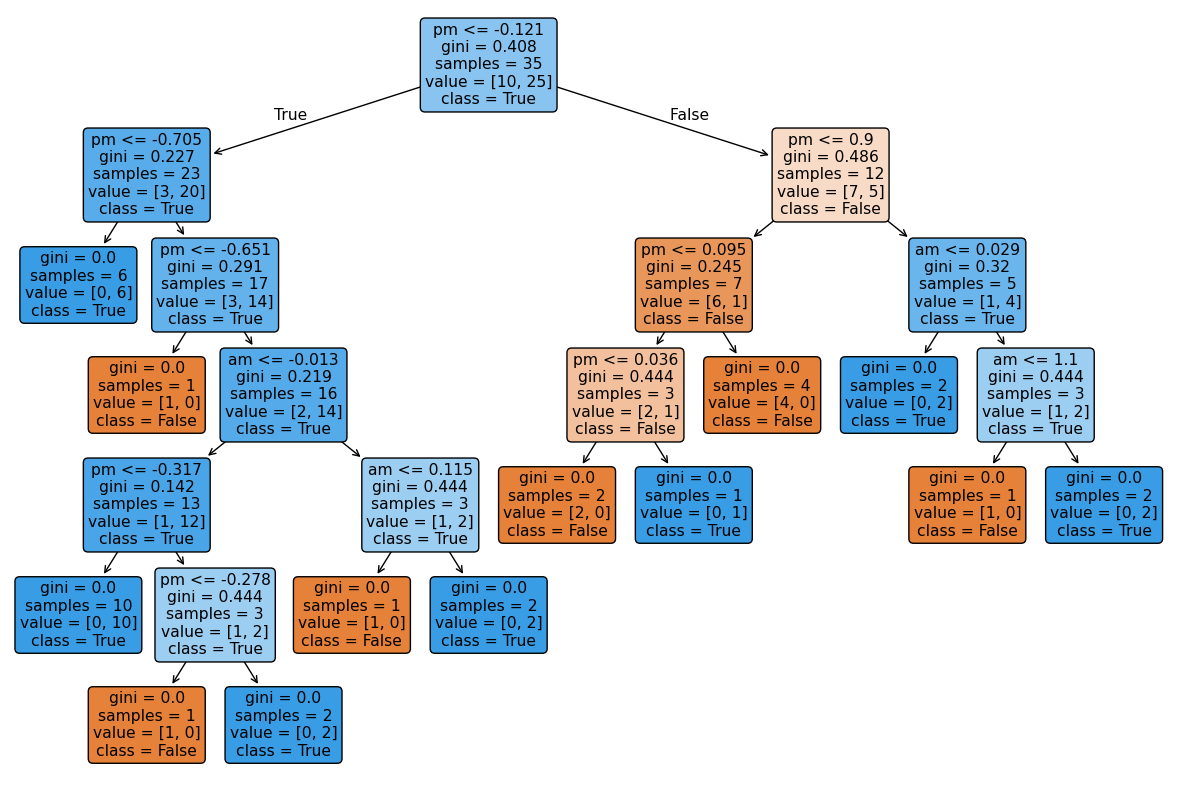

In [41]:
plt.figure(figsize=(15, 10))
plot_tree(dtc, feature_names=['am', 'pm'], class_names=['False', 'True'], filled=True, rounded=True)
plt.show()

# 7 leaves!